In [1]:
library(MASS)
library(leaps)
source("Utils.R")

In [2]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y

hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

### Por ahora dejo esta funcion para poder hacer un filtro de aquelas que tienen mucha correlacion. Cuando veamos como hacer bien el filtro lo eliminamos. 

In [12]:
# Elimina las variables con correlacion mayor a max_corr_acepted
# Retorna el dataframe con las variables nuevas. 
eliminate_variables_high_corr <- function(vasijas_X, max_corr_acepted) {
  new_vasijas_X <- vasijas_X
  are_variables_high_corr <- TRUE
  while (are_variables_high_corr) {
    corr_matrix <- cor(new_vasijas_X, method = "pearson")
    i <- 2
    loop_not_finished <- TRUE
    while (i <= ncol(new_vasijas_X) && loop_not_finished) {
      j <- 1
      while (j <= (i-1) && loop_not_finished) {
        if (corr_matrix[i, j] >= max_corr_acepted) {
          new_vasijas_X <- subset(new_vasijas_X, select = -i)
          loop_not_finished <- FALSE
        }
        if (i == nrow(corr_matrix) && j == nrow(corr_matrix) - 1) {
          are_variables_high_corr <- FALSE
        }
        j <- j + 1
      }
      i <- i + 1
    }
  }
  return(new_vasijas_X)
}

In [32]:
new_vasijas_X <- eliminate_variables_high_corr(TRAIN_X, 0.973)
train_no_high_cor <- new_vasijas_X
train_no_high_cor$Y <- TRAIN_Y
print(paste("Se filtro el dataFrame y quedaron ", ncol(new_vasijas_X), " columnas"))

[1] "Se filtro el dataFrame y quedaron  156  columnas"


### Utilizamos el metodo Forward (utiliza F-Score para elegir variables)

In [38]:
forw<-regsubsets(Y~.,data = train_no_high_cor, method = "forward", nvmax=NULL)

In [36]:
summary(forw)
names(summary(forw))

Subset selection object
Call: regsubsets.formula(Y ~ ., data = train_no_high_cor, method = "forward", 
    nvmax = NULL)
156 Variables  (and intercept)
     Forced in Forced out
V1       FALSE      FALSE
V10      FALSE      FALSE
V11      FALSE      FALSE
V12      FALSE      FALSE
V13      FALSE      FALSE
V14      FALSE      FALSE
V15      FALSE      FALSE
V16      FALSE      FALSE
V17      FALSE      FALSE
V19      FALSE      FALSE
V23      FALSE      FALSE
V26      FALSE      FALSE
V28      FALSE      FALSE
V29      FALSE      FALSE
V30      FALSE      FALSE
V31      FALSE      FALSE
V32      FALSE      FALSE
V33      FALSE      FALSE
V34      FALSE      FALSE
V35      FALSE      FALSE
V36      FALSE      FALSE
V39      FALSE      FALSE
V50      FALSE      FALSE
V52      FALSE      FALSE
V53      FALSE      FALSE
V54      FALSE      FALSE
V55      FALSE      FALSE
V56      FALSE      FALSE
V59      FALSE      FALSE
V61      FALSE      FALSE
V64      FALSE      FALSE
V75      FALSE  

[1] "which"  "rsq"    "rss"    "adjr2"  "cp"     "bic"    "outmat" "obj"

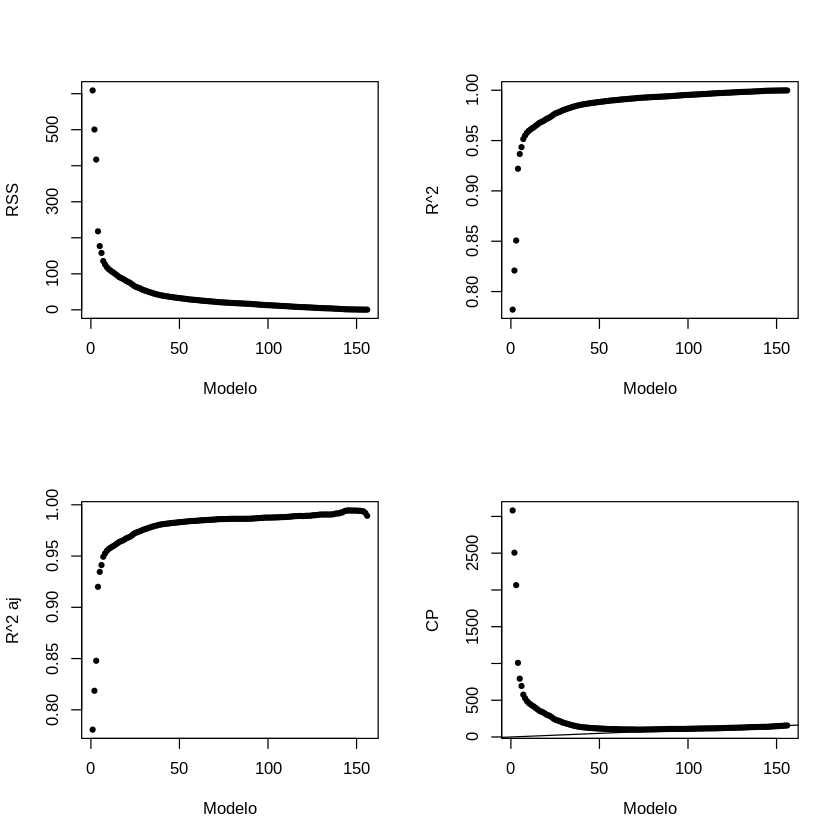

In [39]:
par(mfrow=c(2,2))
plot(summary(forw)$rss,pch=20,xlab="Modelo", ylab= "RSS")

plot(summary(forw)$rsq,pch=20,xlab="Modelo", ylab= "R^2")

plot(summary(forw)$adjr2,pch=20,xlab="Modelo", ylab= "R^2 aj")

plot(summary(forw)$cp,pch=20,xlab="Modelo", ylab= "CP")
abline(0,1)

### No probamos con la función LEAPS para ver todos los casos posibles, por problemas de memoria. Ni siquiera acepta un data-set con tantas variables. 


### Verificacion de supuestos

In [43]:
reg<-lm(Y~.,data = train_no_high_cor)
rest<-rstandard(reg)

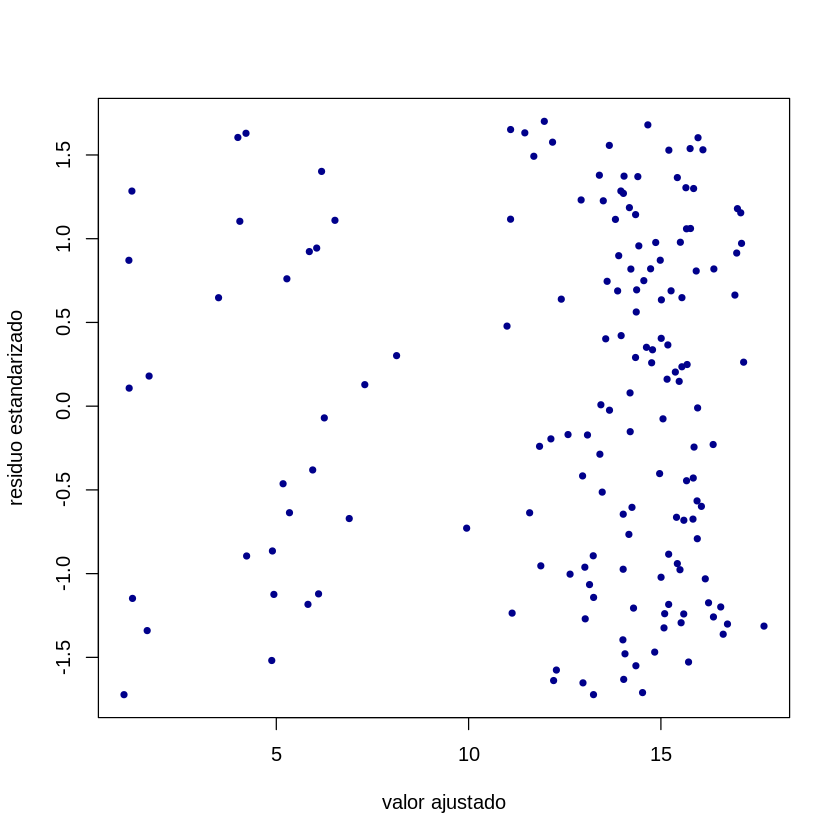

In [44]:
plot(reg$fitted.values,rest, pch=20,col="darkblue",xlab="valor ajustado", 
     ylab="residuo estandarizado")

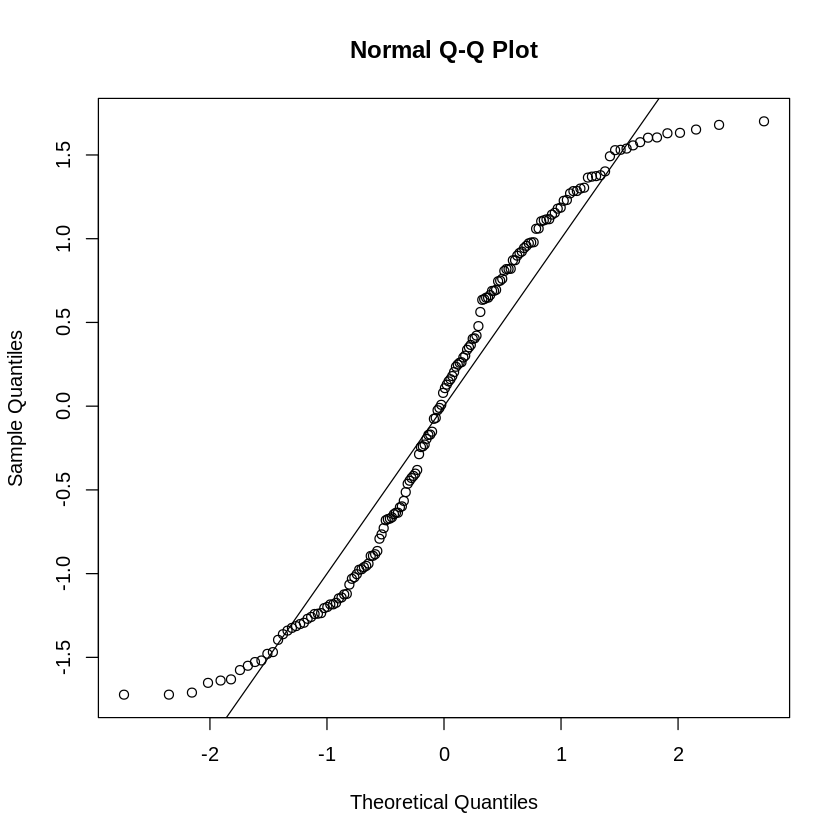

In [46]:
qqnorm(rest)
abline(0, 1)